In [ ]:
import pandas as pd
from COMETH import Skeleton,DynamicSkeleton
# from COMETH.DynamicSkeleton import Kalman
import nimblephysics as nimble
import numpy as np
import time
import matplotlib.pyplot as plt
import os
gui = nimble.NimbleGUI()
gui.serve(8080)
# sudo lsof -iTCP:8080 -sTCP:LISTEN

GUIWebsocketServer will start serving a WebSocket server on ws://localhost:8070
Web GUI serving on http://localhost:8080


127.0.0.1 - - [02/Apr/2026 11:26:39] "GET /?id=d3bd55c1-bc0b-4eac-ba23-cb06bbeb5d4c&vscodeBrowserReqId=1775121999095 HTTP/1.1" 200 -


## Motion sequence: Total Capture Action

In [2]:
gui.nativeAPI().clear()
# Build skeleton
s12 = Skeleton('../COMETH/BODY12.xml')
# BSM
s = DynamicSkeleton()
s.hip_correction = False

# plot xyz axis
axis_length=0.2
gui.nativeAPI().createLine(key='x_axis',points=[np.array([0,0,0]),np.array([axis_length,0,0])],color=np.array([255,0,0,1]))
gui.nativeAPI().createLine(key='y_axis',points=[np.array([0,0,0]),np.array([0,axis_length,0])],color=np.array([0,255,0,1]))
gui.nativeAPI().createLine(key='z_axis',points=[np.array([0,0,0]),np.array([0,0,axis_length])],color=np.array([0,0,255,1]))

# Read data from CSV
markers = pd.read_csv("../inverse_dynamics/data.csv")

# Build the markers dataframe with only the subset we are interested in
Rz = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

Rx = np.array([
    [1,0,0 ],
    [0,0,-1 ],
    [0,1,0]
])

markers.columns
markers_dict = {
'RKnee': 'right_knee',
'LWrist': 'left_wrist',
'RHip': 'right_hip',
'RShoulder': 'right_shoulder',
'LElbow': 'left_elbow',
'LHip': 'left_hip',
'RElbow': 'right_elbow',
'RWrist': 'right_wrist',
'LKnee': 'left_knee',
'LShoulder': 'left_shoulder',
'RAnkle': 'right_ankle',
'LAnkle': 'left_ankle'
 }
target = []
for i in range(markers.shape[0]):
    row = []
    for kp in markers_dict.keys():
        p = np.array([markers[markers_dict[kp]+"_x"][i],markers[markers_dict[kp]+"_y"][i],markers[markers_dict[kp]+"_z"][i]])
        # rotate the 3d point -90 on the x axis (from y up to z up)
        p_n = Rz.dot(Rx.dot(p))
        # print(p,p_n)
        row += p_n.tolist()
    target.append(row)
target = np.array(target)

# Move the body model using gt to the first position
kps = list(markers_dict.keys())
s.reset()
s12.load_from_numpy(target[0,:].reshape(-1,3),s.kps)
s.load_from_BODY12(s12)
s.exact_scale()
gui.nativeAPI().renderSkeleton(s._nimble)

Setting len to 0.1
Setting neutral pos to   0
0.7
  0
Setting len to 0.3
Setting neutral pos to    0
-0.6
   0
Setting len to 0.1
Setting neutral pos to   0
0.2
  0


#### Q without KF

In [4]:
s = DynamicSkeleton()
s.hip_correction = False
s12.load_from_numpy(target[0,:].reshape(-1,3),s.kps)
s.load_from_BODY12(s12)
s.exact_scale()
        
# Move the body model using gt and exact qpik, following input from totalcapture
kps = list(markers_dict.keys())

kf = None

# For stats
Q_es = []
MPJPE = []
for i in range(target.shape[0]):
    s12.load_from_numpy(target[i,:].reshape(-1,3),s.kps)
    s.load_from_BODY12(s12)
    
    # IK
    s.exact_scale(to_scale=False, max_iterations=100)

    # Kalman to estimate velocity and acceleration
    q = s._nimble.getPositions()

    Q_es.append(q)

    gui.nativeAPI().renderSkeleton(s._nimble)
    pos3D = s.to_numpy()
    error = np.linalg.norm(pos3D.reshape(-1,3)-target[i,:].reshape(-1,3), axis=1)
    MPJPE.append(np.mean(error))
avg_MPJPE = np.round(np.mean(MPJPE),2)

print(avg_MPJPE)
s.reset_history()
Q_es = np.array(Q_es)

127.0.0.1 - - [26/Mar/2026 17:29:12] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:29:12] "GET /bundle.js HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:29:13] "GET /favicon.ico HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:29:13] code 404, message File not found
127.0.0.1 - - [26/Mar/2026 17:29:13] "GET /apple-touch-icon-precomposed.png HTTP/1.1" 404 -
127.0.0.1 - - [26/Mar/2026 17:29:13] code 404, message File not found
127.0.0.1 - - [26/Mar/2026 17:29:13] "GET /apple-touch-icon.png HTTP/1.1" 404 -
127.0.0.1 - - [26/Mar/2026 17:29:14] "GET /favicon.ico HTTP/1.1" 200 -
Connection closed.
There are now 0 open connections.
127.0.0.1 - - [26/Mar/2026 17:29:28] "GET /?id=6da4e9bf-ae36-4c7c-96bb-64e32fee0272&vscodeBrowserReqId=1774542568526 HTTP/1.1" 200 -


0.01


## Motion Capture: Human3.6M

In [ ]:
gui.nativeAPI().clear()
# Build skeleton
s12 = Skeleton()
# BSM
s = DynamicSkeleton()
s.hip_correction = False
# plot xyz axis
axis_length=0.2
gui.nativeAPI().createLine(key='x_axis',points=[np.array([0,0,0]),np.array([axis_length,0,0])],color=np.array([255,0,0,1]))
gui.nativeAPI().createLine(key='y_axis',points=[np.array([0,0,0]),np.array([0,axis_length,0])],color=np.array([0,255,0,1]))
gui.nativeAPI().createLine(key='z_axis',points=[np.array([0,0,0]),np.array([0,0,axis_length])],color=np.array([0,0,255,1]))

# Read data from CSV
# markers = pd.read_csv("../inverse_dynamics/S9_Directions.csv")
# markers = pd.read_csv("/home/emartini/nas/MAEVE/HUMAN_MODEL/dataset/csv_clean/S6_Sitting.csv")
# markers = pd.read_csv("/home/emartini/nas/MAEVE/HUMAN_MODEL/dataset/csv_random15/S9_Directions.csv")
# markers = pd.read_csv("/home/emartini/nas/MAEVE/HUMAN_MODEL/dataset/csv_clean/S9_Directions.csv")
markers_gt = pd.read_csv("/home/emartini/nas/MAEVE/HUMAN_MODEL/dataset/csv_clean/S9_Directions.csv")
dt = 0.02

# Build the markers dataframe with only the subset we are interested in
Rz = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

Rx = np.array([
    [1,0,0 ],
    [0,0,-1 ],
    [0,1,0]
])

markers_dict = {
'RKnee': 'RKnee',
'LWrist': 'LWrist',
'RHip': 'RHip',
'RShoulder': 'RShoulder',
'LElbow': 'LElbow',
'LHip': 'LHip',
'RElbow': 'RElbow',
'RWrist': 'RWrist',
'LKnee': 'LKnee',
'LShoulder': 'LShoulder',
'RAnkle': 'RAnkle',
'LAnkle': 'LAnkle'
 }
target = []
for i in range(markers.shape[0]):
    row = []
    for kp in markers_dict.keys():
        p = np.array([markers[markers_dict[kp]+":X"][i],markers[markers_dict[kp]+":Y"][i],markers[markers_dict[kp]+":Z"][i]])
        p_n = p
        row += p_n.tolist()
    target.append(row)
target = np.array(target)

gt = []
for i in range(markers_gt.shape[0]):
    row = []
    for kp in markers_dict.keys():
        p = np.array([markers_gt[markers_dict[kp]+":X"][i],markers_gt[markers_dict[kp]+":Y"][i],markers_gt[markers_dict[kp]+":Z"][i]])
        p_n = p
        row += p_n.tolist()
    gt.append(row)
gt = np.array(gt)
# Move the body model using gt to the first position
kps = list(markers_dict.keys())
s.reset()
s._nimble.setPositions(np.zeros((49,)))
s12.load_from_numpy(gt[0,:].reshape(-1,3),s.kps)
s.load_from_BODY12(s12)
s.exact_scale()
gui.nativeAPI().renderSkeleton(s._nimble)

MPJPE = []
for i in range(target.shape[0]):
    error = np.linalg.norm(target[i,:].reshape(-1,3)-gt[i,:].reshape(-1,3), axis=1)
    MPJPE.append(np.mean(error))

avg_MPJPE_baseline = np.round(np.mean(MPJPE),2)
print(avg_MPJPE_baseline)
    

0.11


In [41]:
s = DynamicSkeleton()
s.hip_correction = False
s12.load_from_numpy(gt[0,:].reshape(-1,3),s.kps)
s._nimble.setPositions(np.zeros((49,)))
s.load_from_BODY12(s12)
s.exact_scale()
        
# Move the body model using gt and exact qpik, following input from totalcapture
kps = list(markers_dict.keys())

kf = None

# For stats
Q_es = []

for i in range(target.shape[0]):
    s12.load_from_numpy(target[i,:].reshape(-1,3),s.kps)
    s.load_from_BODY12(s12)
    
    # IK
    s.exact_scale(to_scale=False, max_iterations=100)

    # Kalman to estimate velocity and acceleration
    q = s._nimble.getPositions()

    Q_es.append(q)

    gui.nativeAPI().renderSkeleton(s._nimble)
    pos3D = s.to_numpy()
    error = np.linalg.norm(pos3D.reshape(-1,3)-gt[i,:].reshape(-1,3), axis=1)
    MPJPE.append(np.mean(error))

avg_MPJPE = np.round(np.mean(MPJPE),2)
print(avg_MPJPE)
    
s.reset_history()
Q_es = np.array(Q_es)

0.01


In [42]:
np.savetxt('../tmp/csv_random15_S9_Directions_IK_gt.csv',Q_es)

## Inverse Dynamics

In [47]:
import numpy as np
import cvxpy as cp
from scipy.sparse.linalg import ArpackError

import numpy as np

def find_c(a, b, n):    
    d = b - a
    dist = np.linalg.norm(d)
    if dist == 0: return a
    c = a + (d / dist) * n
    return c


def diagnose_matrix(name, A, to_print=True):
    U, sv, Vt = np.linalg.svd(A, full_matrices=False)
    if to_print:
        print(f"{name}: shape={A.shape}, σ_max={sv[0]:.2e}, σ_min={sv[-1]:.2e}, "
            f"rank={np.sum(sv > 1e-10)}/{min(A.shape)}, cond={sv[0]/sv[-1]:.2e}")
    return sv

def get_world_contact_points(contact_info):
    """
    Transform contact points for ground constraints definition and plotting.
    """
    world_points = []
    
    for body_node, local_offset, _ in contact_info:
        offset_np = np.array(local_offset).flatten()
        T_world = body_node.getWorldTransform().matrix()
        offset_homo = np.append(offset_np, 1.0)
        world_pos_homo = T_world @ offset_homo
        world_pos = world_pos_homo[:3]
        world_points.append(world_pos)

    return world_points

def estimate_contact_points(skeleton, target = None, floor_z=0.05, chair_z=.7):
    # Body nodes
    left_calcn = skeleton._nimble.getBodyNode("calcn_l")
    right_calcn = skeleton._nimble.getBodyNode("calcn_r")
    femur_l = skeleton._nimble.getBodyNode("femur_l")
    femur_r = skeleton._nimble.getBodyNode("femur_r")

    # Contact points to detect
    contact_info = [
            # Heels
            (left_calcn,  [0.0,  0.0, -0.03],  floor_z ),
            (left_calcn,  [0.0,  0.0, 0.03],   floor_z ),
            (right_calcn, [0.0,  0.0, -0.03],  floor_z ),
            (right_calcn, [0.0,  0.0, 0.03],   floor_z ),
            # Toes
            (left_calcn,  [0.15,  0.0, -0.03],  floor_z ),
            (left_calcn,  [0.15,  0.0, 0.03],   floor_z ),
            (right_calcn, [0.15,  0.0, -0.03],  floor_z ),
            (right_calcn, [0.15,  0.0, 0.03],   floor_z ),
            # femur_l
            (femur_l,      [0.0,  0.05, -0.08],     chair_z ),
            (femur_r,      [0.0,  0.05, 0.08],     chair_z ),
            (femur_l,      [0.0,  -0.15, -0.08],     chair_z ),
            (femur_r,      [0.0,  -0.15, 0.08],     chair_z ),
            # (pelvis,      [0.0,  -0.05, -0.05],     chair_z ),
    ]

    res_world = get_world_contact_points(contact_info)
    to_keep = []

    # Check if point is close enough to ground (0.03 instead of 0.04 for better detection)
    for i, c_point in enumerate(contact_info):
        z_coord = res_world[i][-1]
        z_treshold = c_point[2]
        if z_coord < z_treshold:  # More lenient threshold
            to_keep.append( c_point )
    return to_keep

def get_contact_jacobian_deriv_times_dq(skeleton, contact_info, dq):
    """
    Calcola il termine di accelerazione di bias (dJ_c * dq) per i punti di contatto.        
    Returns:
        dJc_dq: Vettore numpy 1D (24,) contenente le accelerazioni di bias (xyzxyz...)
    """
    
    num_contacts = len(contact_info)
    dJc_dq = np.zeros(num_contacts * 3)
    
    for i, (body_node, offset, _) in enumerate(contact_info):       
        # 1. Estrai la derivata temporale dello Jacobiano Lineare (Matrice 3 x 49)
        # Nimble calcola analiticamente dJ/dt considerando le velocità attuali
        dJ_i = skeleton._nimble.getLinearJacobianDeriv(body_node,offset)
        
        # 2. Moltiplica la matrice per le velocità articolari per ottenere l'accelerazione 3D
        bias_accel_i = dJ_i @ dq
        
        # 3. Inserisci l'accelerazione (x, y, z) nel vettore piatto finale
        idx_start = i * 3
        idx_end = idx_start + 3
        dJc_dq[idx_start:idx_end] = bias_accel_i
        
    return dJc_dq

def get_task_jacobian_derivative_times_dq(skeleton, keypoint_joints, dq):
    """
    Calculate convettive acceleration J_dot * q_dot for each keypoint.
    """
    dJ_dq_list = []
    
    for joint in keypoint_joints:
        body_node = joint.getChildBodyNode() 
        # Get the offset
        T_child = joint.getTransformFromChildBodyNode()
        local_offset = T_child.translation() # numpy array [3, 1] o [3,]
        
        # Extract the jacobian
        J_dot_linear = skeleton._nimble.getLinearJacobianDeriv(body_node, local_offset)
        
        # Calculate convettive acceleration
        acc_conv = J_dot_linear @ dq 
        
        dJ_dq_list.append(acc_conv)
        
    dJ_kp_dq = np.concatenate(dJ_dq_list)
    
    return dJ_kp_dq

def get_contact_jacobian(skeleton, contact_info):
    """
    Calculate contact jacobian.
    """
    J_c_list = []
    
    for body_node, local_offset, _ in contact_info:
        offset_np = np.array(local_offset, dtype=np.float64).reshape(3, 1)
        J_point = skeleton._nimble.getLinearJacobian(body_node, offset_np)
        J_c_list.append(J_point)
        
    J_c = np.vstack(J_c_list)
    
    return J_c

def qpid(skeleton, x_t, dt=0.033, mu=0.8, excluded_DOFs=None, ddq_prev=None, tau_prev=None, steps=1):
    
    if excluded_DOFs is None:
        excluded_DOFs = [
            11, 12,18,19,   
            37,38,47,48,    
            26,27,28,       
            36,46,          
            ]

    n_dof_full = skeleton._nimble.getNumDofs()   
    n_act_full = n_dof_full - 6                  
    
    mask = ~np.isnan(x_t.reshape(-1,3))
    n_kp = int(np.sum(mask[:,0]))
    subsets_joints = [joint for i,joint in enumerate(skeleton.joints) if mask[i,0]]
    
    x_t_flat = x_t[mask.flatten()]

    # --- 1. SETUP INIZIALE E MATRICI STATICHE ---
    active_dofs = [i for i in range(n_dof_full) if i not in excluded_DOFs]
    n_dof = len(active_dofs)  
    
    active_act_dofs = [d for d in active_dofs if d >= 6]
    n_act = len(active_act_dofs)
    
    S_T = np.zeros((n_dof, n_act))
    act_idx = 0
    for i, dof in enumerate(active_dofs):
        if dof >= 6:
            S_T[i, act_idx] = 1.0
            act_idx += 1
            
    S_vb = np.zeros((n_dof, 6))
    for i, dof in enumerate(active_dofs):
        if dof < 6:
            S_vb[i, dof] = 1.0

    # Inizializzazione memorie per la penalità di fluidità
    curr_ddq_prev = np.zeros(n_dof) if ddq_prev is None else ddq_prev[active_dofs]
    curr_tau_prev = np.zeros(n_act) if tau_prev is None else np.array([tau_prev[d - 6] for d in active_act_dofs])

    # Calcolo tempo del micro-step
    dt_sim = dt / steps

    # Posizione di partenza per interpolare morbidamente il target
    x_start = np.array(skeleton._nimble.getJointWorldPositions(subsets_joints)).flatten()

    last_result = None

    # =========================================================
    # --- CICLO DI MICRO-STEPPING INTERNO ---
    # =========================================================
    for step_idx in range(steps):
        
        # Interpolazione del target: calcola il target intermedio per questo specifico micro-step
        alpha = (step_idx + 1) / steps
        x_t_micro = x_start + (x_t_flat - x_start) * alpha

        # --- ESTRAZIONE STATO AGGIORNATO ---
        q = skeleton._nimble.getPositions()
        dq = skeleton._nimble.getVelocities()
        
        M_full = skeleton._nimble.getMassMatrix() + np.eye(n_dof_full) * 1e-6
        H_cg_full = skeleton._nimble.getCoriolisAndGravityForces()
        
        J_kp_full = skeleton._nimble.getJointWorldPositionsJacobianWrtJointPositions(subsets_joints)
        dJ_kp_dq = get_task_jacobian_derivative_times_dq(skeleton, subsets_joints, dq) 
        x_current = np.array(skeleton._nimble.getJointWorldPositions(subsets_joints)).flatten()

        contact_info = estimate_contact_points(skeleton, target=x_t_micro)
        n_contacts = len(contact_info)

        M = M_full[np.ix_(active_dofs, active_dofs)]
        H_cg = H_cg_full[active_dofs]
        J_kp = J_kp_full[:, active_dofs]

        # PD-controller
        Kp = 150.0  
        Kd = 20.0  
        x_dot_current = J_kp_full @ dq 
        x_des_ddot = Kp * (x_t_micro - x_current) - Kd * x_dot_current

        # --- VARIABILI CVXPY ---
        ddq = cp.Variable(n_dof)           
        tau = cp.Variable(n_act)           
        delta = cp.Variable(n_kp * 3)      
        tau_virtual = cp.Variable(6) 

        # --- GESTIONE LIMITI (Usano dt_sim!) ---
        q_L, q_U = skeleton.q_l, skeleton.q_u
        dq_L, dq_U = skeleton.qdot_l * 2, skeleton.qdot_u * 2
        gamma, dt_sq = 0.5, dt_sim**2

        ddq_max_pos = gamma * (q_U - q - (dq * dt_sim)) / dt_sq
        ddq_min_pos = gamma * (q_L - q - (dq * dt_sim)) / dt_sq
        ddq_max_vel = (dq_U - dq) / dt_sim
        ddq_min_vel = (dq_L - dq) / dt_sim
        
        ddq_max_vel = np.minimum(ddq_max_vel, np.ones(ddq_max_vel.shape)*40)
        ddq_min_vel = np.maximum(ddq_min_vel, np.ones(ddq_max_vel.shape)*(-40))

        ddq_ub_full = np.minimum(ddq_max_pos, ddq_max_vel)
        ddq_lb_full = np.maximum(ddq_min_pos, ddq_min_vel)

        infeasible_mask = ddq_lb_full > ddq_ub_full
        if np.any(infeasible_mask):
            mid = 0.5 * (ddq_lb_full + ddq_ub_full)
            ddq_lb_full = np.where(infeasible_mask, mid - 1e-3, ddq_lb_full)
            ddq_ub_full = np.where(infeasible_mask, mid + 1e-3, ddq_ub_full)

        ddq_ub = ddq_ub_full[active_dofs]
        ddq_lb = ddq_lb_full[active_dofs]

        # --- COSTRUZIONE MODULARE CVXPY ---
        dyn_lhs = M @ ddq + H_cg
        dyn_rhs = S_T @ tau + S_vb @ tau_virtual


        # ------------------------------------
        w_ddq = np.ones(n_dof) * 1000
        w_tau = np.ones(n_act) * 100
        w_jerk = np.ones(n_dof) * 1
        w_dtau = np.ones(n_act) * 10       
        w_delta = np.ones(n_kp * 3) * 10000
        w_virtual = np.ones(6) * 1
        w_fc = np.ones(n_contacts * 3) * 1
        w_z = np.ones(n_contacts) * 1000
        # ------------------------------------
        
        cost_expr = (
            w_ddq @ cp.square(ddq) +
            w_jerk @ cp.square(ddq - curr_ddq_prev) +      
            w_tau @ cp.square(tau) +
            w_dtau @ cp.square(tau - curr_tau_prev) +      
            w_delta @ cp.square(delta) +
            w_virtual @ cp.square(tau_virtual)
        )

        constraints = [
            J_kp @ ddq + dJ_kp_dq == x_des_ddot + delta,
            tau <= 100.0,
            tau >= -100.0,
            ddq <= ddq_ub,
            ddq >= ddq_lb,
        ]

        fc_out = np.array([]) 

        if n_contacts > 0:
            J_c_full = get_contact_jacobian(skeleton, contact_info) 
            J_c = J_c_full[:, active_dofs]
            
            fc = cp.Variable(n_contacts * 3)
            delta_z = cp.Variable(n_contacts, nonneg=True)
            
            V = np.zeros((n_contacts * 5, n_contacts * 3))
            for i in range(n_contacts):
                row_idx, col_idx = i * 5, i * 3
                V[row_idx:row_idx+5, col_idx:col_idx+3] = np.array([
                    [-1,  0,  mu], [ 1,  0,  mu], [ 0, -1,  mu], [ 0,  1,  mu], [ 0,  0,  1]
                ])
                
            J_c_z_full = J_c_full[2::3, :]
            J_c_z = J_c_z_full[:, active_dofs]
            
            contact_pts = get_world_contact_points(contact_info)
            z_current = np.array([p[2] for p in contact_pts]) 

            dJ_c_dq_z_full = get_contact_jacobian_deriv_times_dq(skeleton, contact_info, dq)
            dJ_c_dq_z = dJ_c_dq_z_full[2::3]  

            z_ddot = J_c_z @ ddq + dJ_c_dq_z
            v_current_z = J_c_z_full @ dq
            
            # Attenzione: Usiamo dt_sim per l'integrazione del contatto!
            z_next = z_current + (v_current_z * dt_sim) + (z_ddot * (dt_sim**2))

            dyn_rhs += J_c.T @ fc
            
            cost_expr += w_fc @ cp.square(fc) + w_z @ cp.square(delta_z)
            
            constraints.extend([
                V @ fc >= 0,
                z_next + delta_z >= 0
            ])
        
        constraints.append(dyn_lhs == dyn_rhs)

        # --- RISOLUZIONE ---
        problem = cp.Problem(cp.Minimize(cost_expr), constraints)

        try:
            problem.solve(solver=cp.OSQP, warm_start=True)
        except Exception as e:
            print(f"QPID ha fallito con un errore di {e} al micro-step {step_idx}")
            return None
            
        if problem.status not in ["optimal", "optimal_inaccurate"]:
            print(f"Attenzione: l'ottimizzatore ha fallito ({problem.status}) al micro-step {step_idx}")
            return None
            
        # --- RECOSTRUZIONE ARRAYS FULL-SIZE ---
        ddq_out = np.zeros(n_dof_full)
        ddq_out[active_dofs] = ddq.value
        
        tau_out = np.zeros(n_act_full)
        for i, active_dof_idx in enumerate(active_act_dofs):
            tau_out[active_dof_idx - 6] = tau.value[i]

        if n_contacts > 0:
            fc_out = fc.value

        last_result = {
            "ddq": ddq_out,
            "tau": tau_out,
            "fc": fc_out,
            "delta": delta.value,
            "contact_info": contact_info
        }

        # --- INTEGRAZIONE NUMERICA INTERNA E AGGIORNAMENTO SCHELETRO ---
        # Applichiamo l'azione calcolata per far avanzare la fisica prima del prossimo micro-step
        dq_next = dq * 0.999 + ddq_out * dt_sim  # Leggero damping del 0.1% sulle velocità
        q_next = q + dq_next * dt_sim
        
        skeleton._nimble.setPositions(q_next)
        skeleton._nimble.setVelocities(dq_next)
        skeleton._nimble.setAccelerations(ddq_out)
        skeleton._nimble.setControlForces(np.hstack([np.zeros(6), tau_out]))

        # Aggiorniamo le variabili previste per la penalità di fluidità del prossimo step
        curr_ddq_prev = ddq.value
        curr_tau_prev = tau.value

    # Fine del ciclo di micro-stepping, restituiamo i dati dell'ultimo step
    return last_result

s = DynamicSkeleton()
s.hip_correction = False
s._nimble.setPositions(np.zeros((49,)))
s12.load_from_numpy(gt[0,:].reshape(-1,3),s.kps)
s.load_from_BODY12(s12)
s.exact_scale()
T_pose = s._nimble.getPositions()
kps = list(markers_dict.keys())
        
kf = None

# For stats
MPJPE = []
Q , Q_dot , Q_dotdot = [], [], []
s._nimble.setGravity([0,0,-9.81])
s._nimble.setVelocities(np.zeros(49))
s._nimble.setAccelerations(np.zeros(49))
s._nimble.setControlForces(np.zeros(49))

# dt = 0.02

import random

ddq_last = np.zeros(49) # Memoria per la penalità Jerk
tau_last = np.zeros(43) # Memoria per la penalità Torque Rate

results = []
Fc = []
for i in range(0,target.shape[0]):
    s12.load_from_numpy(target[i,:].reshape(-1,3),s.kps)
    target_kps = s12.to_numpy(s.kps,3).reshape(1,-1).squeeze()

    # Robustness TEST: Remove joints
    joints_to_remove = [random.choice(list(range(0,12))) for _ in range(8)]
    joints_to_remove = []
    for j in joints_to_remove:
        target_kps[3*j:3*j+3] = np.nan

    result = qpid(s, target_kps, dt, ddq_prev=ddq_last, tau_prev=tau_last,steps=1) 

    if result is None or result["ddq"] is None:
        print(f"[Step {i}] QP fallito")
        break

    results.append(result)

    ddq_opt = result["ddq"]
    tau_opt = result["tau"]

    ddq_last = ddq_opt.copy()
    tau_last = tau_opt.copy()
    
    q_current = s._nimble.getPositions()
    dq_current = s._nimble.getVelocities()

    Q.append(q_current)
    Q_dot.append(dq_current)
    Q_dotdot.append(s._nimble.getAccelerations())

    pos3D = s.to_numpy()
    error = np.linalg.norm(pos3D.reshape(-1,3)-gt[i,:].reshape(-1,3), axis=1)
    MPJPE.append(np.mean(error))
    avg_MPJPE = np.round(np.mean(MPJPE),2)

    # Visualization
    # contact_estimated = np.array(get_world_contact_points(estimate_contact_points(s,target_kps)))
    contact_estimated = np.array(get_world_contact_points(result["contact_info"]))
    fc = result["fc"].reshape(-1,3)
    for j in range(8):
        if j < contact_estimated.shape[0]:
            gui.nativeAPI().createSphere(key=f"contact:{j}", radii=np.array([0.03,0.03,0.03]),pos=contact_estimated[j,:],color=np.array([255,0,0,1]))
        else:
            gui.nativeAPI().createSphere(key=f"contact:{j}", radii=np.array([0.03,0.03,0.03]),pos=np.zeros(3),color=np.array([0,0,0,0]))

    for j in range(12):
        if j not in joints_to_remove:
            gui.nativeAPI().createSphere(key=str(j), radii=np.array([0.02,0.02,0.02]),pos=target[i,3*j:3*j+3],color=np.array([0,0,0,1]))
        gui.nativeAPI().createSphere(key=str(j)+"_gt", radii=np.array([0.02,0.02,0.02]),pos=gt[i,3*j:3*j+3],color=np.array([0,255,0,1]))
    gui.nativeAPI().renderSkeleton(s._nimble)
print(f"Step {i} - \tMPJPE frame: {np.round(np.mean(error),2)}\tMPJPE average: {avg_MPJPE}")
    # time.sleep(dt)

Step 2698 - 	MPJPE frame: 0.14	MPJPE average: 0.07


In [48]:
np.savetxt('../tmp/csv_random15_S9_Directions_ID.csv',Q)

### Older versions

In [8]:
dofs_names = [
    'root_rotation:x',
    'root_rotation:y',
    'root_rotation:z',
    'root_translation:x',
    'root_translation:y',
    'root_translation:z',
    'hip_flexion_r',
    'hip_adduction_r',
    'hip_rotation_r',
    'knee_flexion_r',
    'ankle_r',
    'subtalar_r',
    'mtp_r',
    'hip_flexion_l',
    'hip_adduction_l',
    'hip_rotation_l',
    'knee_flexion_l',
    'ankle_l',
    'subtalar_l',
    'mtp_l',
    'lumbar_bending',
    'lumbar_extension',
    'lumbar_twist',
    'thorax_bending',
    'thorax_extension',
    'thorax_twist',
    'head_bending',
    'head_extension',
    'head_twisti',
    'scapular_abduction_r',
    'scapular_elevation_r',
    'scapular_upward_rotation_r',
    'shoulder_abduction_r',
    'shoulder_rotation_r',
    'shoulder_flexion_r',
    'elbow_flexion_r',
    'elbow_pronation_r',
    'wrist1_r',
    'wrist2_r',
    'scapular_abduction_l',
    'scapular_elevation_l',
    'scapular_upward_rotation_l',
    'shoulder_abduction_l',
    'shoulder_rotation_l',
    'shoulder_flexion_l',
    'elbow_flexion_l',
    'elbow_pronation_l',
    'wrist1_l',
    'wrist2_l',
]

print([(i,dof_name) for i,dof_name in enumerate(dofs_names)])

[(0, 'root_rotation:x'), (1, 'root_rotation:y'), (2, 'root_rotation:z'), (3, 'root_translation:x'), (4, 'root_translation:y'), (5, 'root_translation:z'), (6, 'hip_flexion_r'), (7, 'hip_adduction_r'), (8, 'hip_rotation_r'), (9, 'knee_flexion_r'), (10, 'ankle_r'), (11, 'subtalar_r'), (12, 'mtp_r'), (13, 'hip_flexion_l'), (14, 'hip_adduction_l'), (15, 'hip_rotation_l'), (16, 'knee_flexion_l'), (17, 'ankle_l'), (18, 'subtalar_l'), (19, 'mtp_l'), (20, 'lumbar_bending'), (21, 'lumbar_extension'), (22, 'lumbar_twist'), (23, 'thorax_bending'), (24, 'thorax_extension'), (25, 'thorax_twist'), (26, 'head_bending'), (27, 'head_extension'), (28, 'head_twisti'), (29, 'scapular_abduction_r'), (30, 'scapular_elevation_r'), (31, 'scapular_upward_rotation_r'), (32, 'shoulder_abduction_r'), (33, 'shoulder_rotation_r'), (34, 'shoulder_flexion_r'), (35, 'elbow_flexion_r'), (36, 'elbow_pronation_r'), (37, 'wrist1_r'), (38, 'wrist2_r'), (39, 'scapular_abduction_l'), (40, 'scapular_elevation_l'), (41, 'scapul

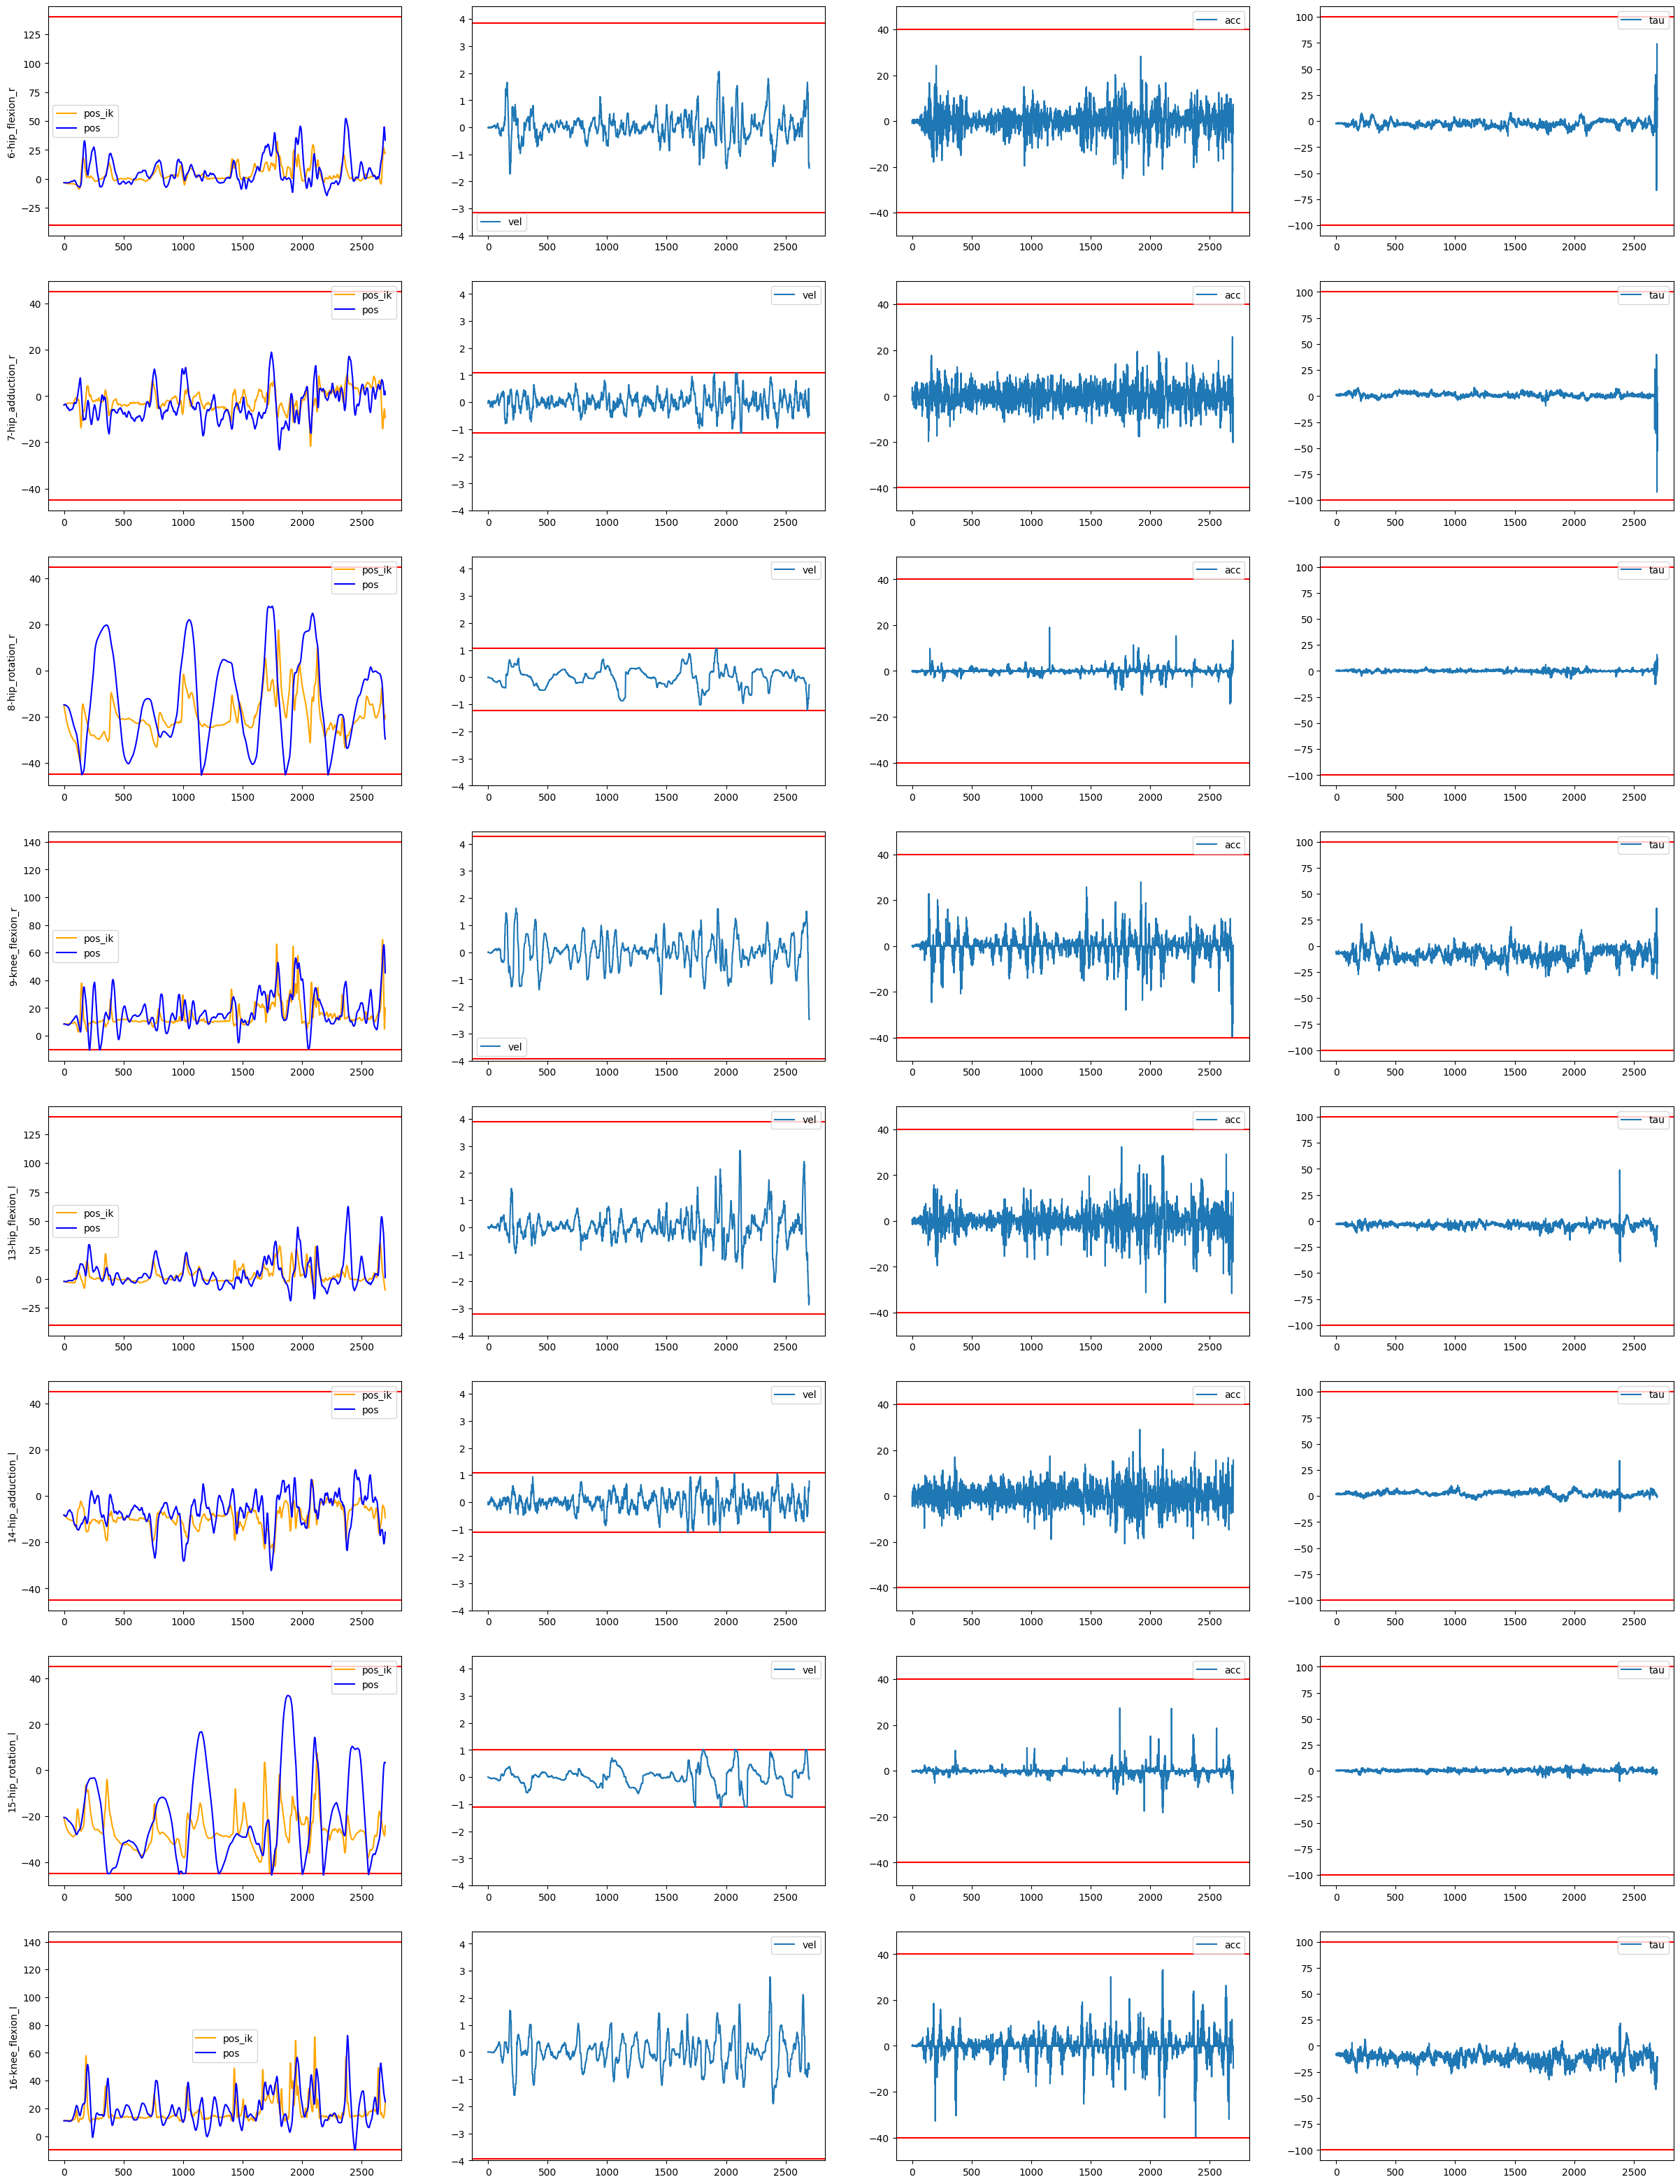

In [35]:
results[0].keys()
TAU = [results[i]["tau"] for i in range(len(results)-1)]
TAU = np.array(TAU)

# dofs = list(range(6,49))
dofs = list(range(6,10))+list(range(13,17))
fig, axs = plt.subplots(len(dofs),4,figsize=(30,5*len(dofs)))
# fig.suptitle('Right Hip Flexion')
for i, dof in enumerate(dofs):
    Q = np.array(Q)
    axs[i,0].plot(np.degrees(Q_es[:Q.shape[0],dof]),color='orange',label=f'pos_ik')
    axs[i,0].axhline(y=np.degrees(s.q_u[dof]), color='r', linestyle='-')
    axs[i,0].axhline(y=np.degrees(s.q_l[dof]), color='r', linestyle='-')
    axs[i,0].plot(np.degrees(Q[:,dof]),color='b',label=f'pos')
    axs[i,0].set_ylabel(f"{dof}-{dofs_names[dof]}")
    axs[i,0].legend()

    Q_dot = np.array(Q_dot)
    axs[i,1].axhline(y=2*s.qdot_u[dof], color='r', linestyle='-')
    axs[i,1].axhline(y=2*s.qdot_l[dof], color='r', linestyle='-')
    axs[i,1].plot(Q_dot[:,dof],label=f'vel')
    axs[i,1].set_ylim(2*np.min(s.qdot_l), 2*np.max(s.qdot_u))
    axs[i,1].legend()

    Q_dotdot = np.array(Q_dotdot)
    axs[i,2].plot(Q_dotdot[:,dof],label=f'acc')
    axs[i,2].legend()
    axs[i,2].set_ylim(-50, 50)
    axs[i,2].axhline(y=-40, color='r', linestyle='-')
    axs[i,2].axhline(y=40, color='r', linestyle='-')


    axs[i,3].plot(TAU[:,dof-6],label=f'tau')
    axs[i,3].set_ylim(-110,110)
    axs[i,3].axhline(y=-100, color='r', linestyle='-')
    axs[i,3].axhline(y=100, color='r', linestyle='-')
    
    axs[i,3].legend()

In [ ]:
# import matplotlib.pyplot as plt

Fc = np.array(Fc)

# plt.plot(Q_dotdot[:,32], label = "kf")
# plt.show()

fig, axs = plt.subplots(2,2,sharex=True, figsize=(30, 15))

axs[0,0].plot(Fc[:,3*0+2],label=f'Fz Lcalc L')
axs[0,0].plot(Fc[:,3*1+2],label=f'Fz Lcalc R')

axs[0,0].plot(Fc[:,3*2+2],label=f'Fz Ltoes L')
axs[0,0].plot(Fc[:,3*3+2],label=f'Fz Ltoes R')

axs[0,1].plot(Fc[:,3*4+2],label=f'Fz Rcalc L')
axs[0,1].plot(Fc[:,3*5+2],label=f'Fz Rcalc R')

axs[0,1].plot(Fc[:,3*6+2],label=f'Fz Rtoes L')
axs[0,1].plot(Fc[:,3*7+2],label=f'Fz Rtoes R')


axs[1,0].plot(target[:Fc.shape[0],32],label=f'LAnkle Z')
axs[1,0].plot(target[:Fc.shape[0],35],label=f'RAnkle Z')
axs[1,1].plot(target[:Fc.shape[0],32],label=f'LAnkle Z')
axs[1,1].plot(target[:Fc.shape[0],35],label=f'RAnkle Z')

axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
plt.show()

In [ ]:
Fc_mean_l = np.mean(Fc[:,[3*0+2,3*1+2,3*2+2,3*3+2]],1)
Fc_mean_r = np.mean(Fc[:,[3*4+2,3*5+2,3*6+2,3*7+2]],1)

fig, axs = plt.subplots(2,sharex=True, figsize=(30, 15))

axs[0].set_xlabel('time (s)')
axs[0].set_ylabel('Fc (N)')
axs[0].plot(Fc_mean_l,label=f'Fz Avg L')
axs[0].tick_params(axis='y')
ax2 = axs[0].twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('Z Ankle position (m)')  # we already handled the x-label with ax1
ax2.plot(target[:Fc.shape[0],35],label=f'LAnkle Z',color='r')
ax2.tick_params(axis='y')

axs[1].set_xlabel('time (s)')
axs[1].set_ylabel('Fc (N)')
axs[1].plot(Fc_mean_r,label=f'Fz Avg R')
axs[1].tick_params(axis='y')
ax2 = axs[1].twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('Z Ankle position (m)')  # we already handled the x-label with ax1
ax2.plot(target[:Fc.shape[0],32],label=f'RAnkle Z',color='r')
ax2.tick_params(axis='y')
# axs[0,1].plot(Fc_mean_r,label=f'Fz Avg R')

# axs[0,1].plot(Fc[:,3*4+2],label=f'Fz Rcalc L')
# axs[0,1].plot(Fc[:,3*5+2],label=f'Fz Rcalc R')

# axs[0,1].plot(Fc[:,3*6+2],label=f'Fz Rtoes L')
# axs[0,1].plot(Fc[:,3*7+2],label=f'Fz Rtoes R')


# axs[1,1].plot(target[:Fc.shape[0],32],label=f'RAnkle Z')

axs[0].legend()
axs[1].legend()

# axs[1,0].legend()
# axs[1,1].legend()
# plt.show()

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()